# 套索肽 (Lasso Peptide) 分类器

胃肠道蛋白中套索肽的人工智能分类模型。

**流程**: FASTA 序列 → ESM-2 特征提取 → CNN + Attention → 套索肽概率

---

In [1]:
# ============================================================
# 配置开关
# ============================================================
QUICK_MODE = False     # True: 仅用少量数据测试流程; False: 完整训练
QUICK_SAMPLES = 100   # 速跑模式下每种样本取多少条
FORCE_REDOWNLOAD = False  # 是否强制重新下载数据

In [2]:
# ============================================================
# 1. 环境准备 — 安装依赖
# ============================================================
import sys
print(f'Python: {sys.version[:6]}')

Python: 3.12.3


In [3]:
# ============================================================
# 2. 导入依赖
# ============================================================
import os
import warnings
import requests
import subprocess
import numpy as np
import pandas as pd
from time import time
from copy import deepcopy
from tqdm.notebook import tqdm
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report,
    precision_recall_curve
)
from Bio import SeqIO
from Bio.Seq import Seq
from transformers import EsmTokenizer, EsmModel

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

print(f'Torch: {torch.__version__}, CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB)')

Torch: 2.6.0+cu124, CUDA: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU (4.0 GB)


In [4]:
# ============================================================
# 3. 全局配置
# ============================================================
class Config:
    # 路径
    DATA_DIR = './lasso_data'
    DATASET_DIR = './lasso_dataset'
    CKPT_DIR = './lasso_checkpoints'
    RESULTS_DIR = './lasso_results'
    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(DATASET_DIR, exist_ok=True)
    os.makedirs(CKPT_DIR, exist_ok=True)
    os.makedirs(RESULTS_DIR, exist_ok=True)

    RAW_POS = os.path.join(DATA_DIR, 'raw_positives.fasta')
    RAW_NEG = os.path.join(DATA_DIR, 'raw_negatives.fasta')
    CLEAN_POS = os.path.join(DATA_DIR, 'clean_positives.fasta')
    CLEAN_NEG = os.path.join(DATA_DIR, 'clean_negatives.fasta')
    TRAIN_PT = os.path.join(DATASET_DIR, 'train.pt')
    VAL_PT = os.path.join(DATASET_DIR, 'val.pt')
    TEST_PT = os.path.join(DATASET_DIR, 'test.pt')

    # ESM-2
    ESM_MODEL = 'facebook/esm2_t12_35M_UR50D'
    ESM_EMBED_DIM = 480  # t12_35M 的隐藏维度
    ESM_BATCH_SIZE = 4   # 4GB 显存需调低
    MAX_LEN = 100

    # CD-HIT
    CD_HIT_THRESHOLD = 0.5

    # 训练
    BATCH_SIZE = 32
    EPOCHS = 60 if not QUICK_MODE else 10
    LR = 1e-4
    WEIGHT_DECAY = 1e-5
    PATIENCE = 10
    DROPOUT = 0.3

    # 模型
    CNN_CHANNELS = [128, 128, 256]
    CNN_KERNELS = [5, 3, 3]
    ATTENTION_HEADS = 4
    MLP_HIDDEN = 64

    # 随机种子
    SEED = 42

cfg = Config()
torch.manual_seed(cfg.SEED)
np.random.seed(cfg.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Config loaded. Device: {device}')
print(f'{'='*40}\n  QUICK_MODE = {QUICK_MODE}\n  ESM: {cfg.ESM_MODEL}\n  Epochs: {cfg.EPOCHS}\n{'='*40}')

Config loaded. Device: cuda
  QUICK_MODE = False
  ESM: facebook/esm2_t12_35M_UR50D
  Epochs: 60


---
## 第一步：数据获取

从两个来源获取数据：
- **正样本**: [LassoPred](https://lassopred.accre.vanderbilt.edu/) 数据库的已知套索肽
- **负样本**: [UniProt Swiss-Prot](https://www.uniprot.org/) 中细菌非套索肽蛋白

In [5]:
def fetch_lassopred(output_fasta):
    """从 LassoPred API 下载已知套索肽序列"""
    url = 'https://lassopred.accre.vanderbilt.edu/api/data/?page=1&size=4029'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

    r = requests.get(url, headers=headers)
    r.raise_for_status()
    data = r.json()['data']

    valid = 0
    with open(output_fasta, 'w') as f:
        for item in data:
            seq = item.get('Precursor_Sequence', '').strip()
            seq_id = item.get('LP_ID', '')
            if seq:
                f.write(f'>{seq_id}\n{seq}\n')
                valid += 1
    return valid


def fetch_uniprot_negatives(output_fasta, limit=20000):
    """从 UniProt 下载非套索肽细菌序列作为负样本"""
    query = 'taxonomy_id:2 AND length:[40 TO 100] AND reviewed:true NOT family:"lasso peptide"'
    url = 'https://rest.uniprot.org/uniprotkb/stream'
    params = {'query': query, 'format': 'fasta', 'size': limit}

    r = requests.get(url, params=params, stream=True)
    r.raise_for_status()

    cnt = 0
    with open(output_fasta, 'w') as f:
        for line in r.iter_lines(decode_unicode=True):
            if line:
                f.write(line + '\n')
                if line.startswith('>'):
                    cnt += 1
                if cnt >= limit:
                    break
    return cnt

In [6]:
t0 = time()

if not os.path.exists(cfg.RAW_POS) or FORCE_REDOWNLOAD:
    n = fetch_lassopred(cfg.RAW_POS)
    print(f'[+] 正样本下载完成: {n} 条 → {cfg.RAW_POS}')
else:
    n = len(list(SeqIO.parse(cfg.RAW_POS, 'fasta')))
    print(f'[~] 文件已存在: {cfg.RAW_POS} ({n} 条)')

if not os.path.exists(cfg.RAW_NEG) or FORCE_REDOWNLOAD:
    limit = QUICK_SAMPLES * 2 if QUICK_MODE else 20000
    m = fetch_uniprot_negatives(cfg.RAW_NEG, limit=limit)
    print(f'[+] 负样本下载完成: {m} 条 → {cfg.RAW_NEG}')
else:
    m = len(list(SeqIO.parse(cfg.RAW_NEG, 'fasta')))
    print(f'[~] 文件已存在: {cfg.RAW_NEG} ({m} 条)')

print(f'[i] 耗时: {time()-t0:.1f}s')

[+] 正样本下载完成: 4029 条 → ./lasso_data/raw_positives.fasta
[+] 负样本下载完成: 20000 条 → ./lasso_data/raw_negatives.fasta
[i] 耗时: 103.3s


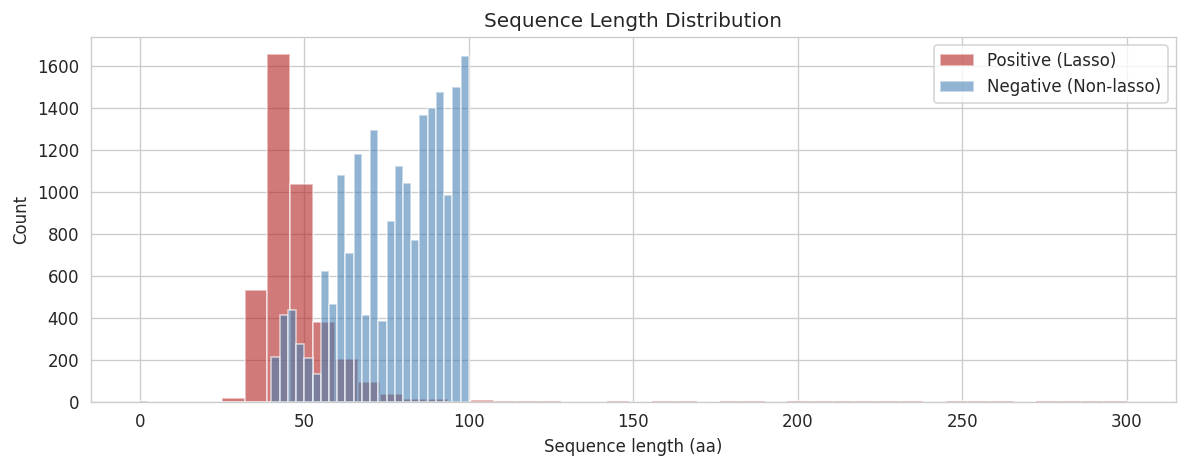

Positive: 4029 seqs, mean len = 48.6
Negative: 20000 seqs, mean len = 77.7


In [7]:
# 序列长度分布可视化
def plot_seq_length_dist(fasta_path, label, color):
    lengths = [len(r.seq) for r in SeqIO.parse(fasta_path, 'fasta')]
    if QUICK_MODE:
        lengths = lengths[:QUICK_SAMPLES]
    plt.hist(lengths, bins=40, alpha=0.6, label=label, color=color, edgecolor='white')
    return lengths

plt.figure(figsize=(10, 4))
pos_len = plot_seq_length_dist(cfg.RAW_POS, 'Positive (Lasso)', 'firebrick')
neg_len = plot_seq_length_dist(cfg.RAW_NEG, 'Negative (Non-lasso)', 'steelblue')
plt.xlabel('Sequence length (aa)')
plt.ylabel('Count')
plt.legend()
plt.title('Sequence Length Distribution')
plt.tight_layout()
plt.show()

print(f'Positive: {len(pos_len)} seqs, mean len = {np.mean(pos_len):.1f}')
print(f'Negative: {len(neg_len)} seqs, mean len = {np.mean(neg_len):.1f}')

---
## 第二步：CD-HIT 去冗余

去除同源序列（序列相似度 > 50%）以防止数据泄露。

In [8]:
def run_cd_hit(in_fasta, out_fasta, threshold=0.5):
    if not os.path.exists(in_fasta):
        print(f'[!] 输入文件不存在: {in_fasta}')
        return False
    if os.path.exists(out_fasta):
        n = len(list(SeqIO.parse(out_fasta, 'fasta')))
        print(f'[~] CD-HIT 结果已存在: {out_fasta} ({n} 条)')
        return True
    cmd = f'cd-hit -i {in_fasta} -o {out_fasta} -c {threshold} -n 3 -M 0 -d 0'
    try:
        subprocess.run(cmd, shell=True, check=True, stdout=subprocess.DEVNULL)
        n_before = len(list(SeqIO.parse(in_fasta, 'fasta')))
        n_after = len(list(SeqIO.parse(out_fasta, 'fasta')))
        print(f'[+] CD-HIT 完成: {n_before} → {n_after} 条 (去冗余 {((1-n_after/n_before)*100):.1f}%)')
        return True
    except subprocess.CalledProcessError as e:
        print(f'[!] CD-HIT 失败 (可能未安装): {e}')
        print('[i] 跳过去冗余，直接使用原始数据')
        return False

In [9]:
# 速跑模式下无需 CD-HIT
if QUICK_MODE:
    # 直接截取前 N 条
    for src, dst in [(cfg.RAW_POS, cfg.CLEAN_POS), (cfg.RAW_NEG, cfg.CLEAN_NEG)]:
        recs = list(SeqIO.parse(src, 'fasta'))[:QUICK_SAMPLES]
        SeqIO.write(recs, dst, 'fasta')
        print(f'[+] 速跑模式: 取 {len(recs)} 条 → {dst}')
else:
    run_cd_hit(cfg.RAW_POS, cfg.CLEAN_POS, cfg.CD_HIT_THRESHOLD)
    run_cd_hit(cfg.RAW_NEG, cfg.CLEAN_NEG, cfg.CD_HIT_THRESHOLD)

[+] CD-HIT 完成: 4029 → 1263 条 (去冗余 68.7%)
[+] CD-HIT 完成: 20000 → 2234 条 (去冗余 88.8%)


---
## 第三步：ESM-2 特征提取

使用预训练的 ESM-2 模型将蛋白质序列转换为数值张量。

**为什么用 ESM-2?**
ESM-2 在 6500 万蛋白质序列上预训练，能捕获进化信息和结构约束。
我们冻结 ESM-2（不更新权重），将其作为特征提取器，训练上层的分类头。

**输出形状**: `(样本数, max_len=100, embed_dim=480)`

In [10]:
def extract_esm2(fasta_file, model_name, batch_size, max_len):
    """
    用 ESM-2 提取蛋白质序列的深度特征。
    返回: (ids, embeddings)
        ids: List[str]
        embeddings: torch.Tensor of shape (N, max_len, embed_dim)
    """
    print(f'[ ] 加载 ESM-2: {model_name} ...')
    tokenizer = EsmTokenizer.from_pretrained(model_name)
    model = EsmModel.from_pretrained(model_name)
    model.to(device)
    model.eval()

    records = list(SeqIO.parse(fasta_file, 'fasta'))
    sequences = [str(r.seq) for r in records]
    ids = [r.id for r in records]
    print(f'[ ] 提取 {len(sequences)} 条序列的特征...')

    all_embeds = []
    t0 = time()
    with torch.no_grad():
        for i in tqdm(range(0, len(sequences), batch_size), desc='ESM-2'):
            batch = sequences[i:i + batch_size]
            inputs = tokenizer(
                batch, return_tensors='pt',
                padding='max_length', max_length=max_len, truncation=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            hidden = outputs.last_hidden_state  # (B, L, D)
            # 对 padding 位置置零
            mask = inputs['attention_mask'].unsqueeze(-1).float()
            hidden = hidden * mask
            all_embeds.append(hidden.cpu())

    print(f'[+] 完成! 耗时: {time()-t0:.1f}s, 形状: {all_embeds[0].shape}')
    return ids, torch.cat(all_embeds, dim=0)

In [11]:
t0 = time()
pos_ids, pos_feat = extract_esm2(cfg.CLEAN_POS, cfg.ESM_MODEL, cfg.ESM_BATCH_SIZE, cfg.MAX_LEN)
pos_labels = torch.ones(pos_feat.size(0), 1)
print(f'正样本特征: {pos_feat.shape}')
print(f'正样本提取耗时: {time()-t0:.1f}s')

[ ] 加载 ESM-2: facebook/esm2_t12_35M_UR50D ...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[ ] 提取 1263 条序列的特征...


ESM-2:   0%|          | 0/316 [00:00<?, ?it/s]

[+] 完成! 耗时: 7.1s, 形状: torch.Size([4, 100, 480])
正样本特征: torch.Size([1263, 100, 480])
正样本提取耗时: 9.6s


In [12]:
t0 = time()
neg_ids, neg_feat = extract_esm2(cfg.CLEAN_NEG, cfg.ESM_MODEL, cfg.ESM_BATCH_SIZE, cfg.MAX_LEN)
neg_labels = torch.zeros(neg_feat.size(0), 1)
print(f'负样本特征: {neg_feat.shape}')
print(f'负样本提取耗时: {time()-t0:.1f}s')

[ ] 加载 ESM-2: facebook/esm2_t12_35M_UR50D ...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[ ] 提取 2234 条序列的特征...


ESM-2:   0%|          | 0/559 [00:00<?, ?it/s]

[+] 完成! 耗时: 11.3s, 形状: torch.Size([4, 100, 480])
负样本特征: torch.Size([2234, 100, 480])
负样本提取耗时: 12.5s


---
## 第四步：数据集划分 & 保存

采用 8:1:1 比例划分训练/验证/测试集，并按类别分层抽样。

In [13]:
# 平衡负样本 (最多取正样本 3 倍，减少类别不平衡)
if neg_feat.size(0) > pos_feat.size(0) * 3:
    idx = torch.randperm(neg_feat.size(0))[:pos_feat.size(0) * 3]
    neg_feat = neg_feat[idx]
    neg_labels = neg_labels[idx]
    neg_ids = [neg_ids[i] for i in idx]
    print(f'[i] 负样本降采样至 {neg_feat.size(0)} 条 (正样本 x3)')

# 合并
X = torch.cat([pos_feat, neg_feat], dim=0)
y = torch.cat([pos_labels, neg_labels], dim=0)
all_ids = pos_ids + neg_ids

print(f'总样本: {X.shape[0]}  (正:{pos_feat.size(0)}, 负:{neg_feat.size(0)})')
print(f'特征矩阵: {X.shape}')
print(f'分布: 正={y.mean().item()*100:.1f}%, 负={(1-y.mean().item())*100:.1f}%')

总样本: 3497  (正:1263, 负:2234)
特征矩阵: torch.Size([3497, 100, 480])
分布: 正=36.1%, 负=63.9%


In [14]:
# 划分 (8:1:1)
X_t, X_test, y_t, y_test, id_t, id_test = train_test_split(
    X, y, all_ids, test_size=0.1, random_state=cfg.SEED, stratify=y
)
X_train, X_val, y_train, y_val, id_train, id_val = train_test_split(
    X_t, y_t, id_t, test_size=0.111, random_state=cfg.SEED, stratify=y_t
)

print(f'Training:   {X_train.shape[0]}  (正:{int(y_train.sum())}, 负:{int((1-y_train).sum())})')
print(f'Validation: {X_val.shape[0]}  (正:{int(y_val.sum())}, 负:{int((1-y_val).sum())})')
print(f'Test:       {X_test.shape[0]}  (正:{int(y_test.sum())}, 负:{int((1-y_test).sum())})')

# 保存
for path, x, y_, ids_ in [
    (cfg.TRAIN_PT, X_train, y_train, id_train),
    (cfg.VAL_PT, X_val, y_val, id_val),
    (cfg.TEST_PT, X_test, y_test, id_test),
]:
    torch.save({'X': x, 'y': y_.squeeze(1), 'ids': ids_}, path)
print(f'[+] 数据集保存至 {cfg.DATASET_DIR}/')

Training:   2797  (正:1011, 负:1786)
Validation: 350  (正:126, 负:224)
Test:       350  (正:126, 负:224)
[+] 数据集保存至 ./lasso_dataset/


---
## 第五步：模型定义

**架构**：
```
ESM-2 Embedding (N, 100, 480)
        ↓ (permute)
Conv1D × 3 (k=5 → 3 → 3)  ← 捕获局部 motif（套索肽环区）
        ↓
Multi-Head Attention        ← 捕获全局依赖（尾部穿线）
        ↓
Global Average Pooling
        ↓
MLP (256 → 64 → 1)
        ↓
Sigmoid → 套索肽概率
```

In [15]:
class LassoPeptideClassifier(nn.Module):
    def __init__(self, embed_dim=480, dropout=0.3):
        super().__init__()
        cnn_channels = [128, 128, 256]
        cnn_kernels = [5, 3, 3]

        in_ch = embed_dim
        self.convs = nn.ModuleList()
        for ch, k in zip(cnn_channels, cnn_kernels):
            block = nn.Sequential(
                nn.Conv1d(in_ch, ch, k, padding=k // 2),
                nn.BatchNorm1d(ch),
                nn.ReLU(),
                nn.MaxPool1d(2),
            )
            self.convs.append(block)
            in_ch = ch

        attn_dim = cnn_channels[-1]
        self.attn = nn.MultiheadAttention(attn_dim, num_heads=4, batch_first=True)
        self.attn_norm = nn.LayerNorm(attn_dim)

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(attn_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: (B, L, D)
        x = x.permute(0, 2, 1)  # (B, D, L)
        for conv in self.convs:
            x = conv(x)
        x = x.permute(0, 2, 1)  # (B, L', C)
        attn_out, _ = self.attn(x, x, x)
        x = self.attn_norm(x + attn_out)
        x = x.mean(dim=1)  # global avg pool
        return self.classifier(x)


model = LassoPeptideClassifier(embed_dim=cfg.ESM_EMBED_DIM, dropout=cfg.DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'模型参数量: {n_params:,}')
print(model)

模型参数量: 736,385
LassoPeptideClassifier(
  (convs): ModuleList(
    (0): Sequential(
      (0): Conv1d(480, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (attn): MultiheadAttention(
    (out_proj): 

---
## 第六步：训练

关键设置：
- **Loss**: BCEWithLogitsLoss (带正样本权重，缓解类别不平衡)
- **优化器**: AdamW (lr=1e-4, weight decay=1e-5)
- **调度器**: CosineAnnealingLR
- **早停**: 验证集 F1 连续 10 个 epoch 不提升则停止

In [16]:
class LassoDataset(Dataset):
    def __init__(self, pt_path):
        data = torch.load(pt_path)
        self.X = data['X']
        self.y = data['y'].unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_set = LassoDataset(cfg.TRAIN_PT)
val_set = LassoDataset(cfg.VAL_PT)
test_set = LassoDataset(cfg.TEST_PT)

train_loader = DataLoader(train_set, batch_size=cfg.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=cfg.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=cfg.BATCH_SIZE, shuffle=False)

pos_weight = ((train_set.y == 0).sum() / (train_set.y == 1).sum()).to(device)
print(f'正样本权重: {pos_weight.item():.2f}')

正样本权重: 1.77


In [17]:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)

In [18]:
def compute_metrics(y_true, y_pred, y_prob):
    y_t = y_true.cpu().numpy().ravel() if torch.is_tensor(y_true) else y_true
    y_p = y_pred.cpu().numpy().ravel() if torch.is_tensor(y_pred) else y_pred
    y_pr = y_prob.cpu().numpy().ravel() if torch.is_tensor(y_prob) else y_prob
    n_cls = len(np.unique(y_t))
    auc_val = roc_auc_score(y_t, y_pr) if n_cls > 1 else float('nan')
    return {
        'loss': None,
        'acc': accuracy_score(y_t, y_p),
        'prec': precision_score(y_t, y_p, zero_division=0),
        'rec': recall_score(y_t, y_p, zero_division=0),
        'f1': f1_score(y_t, y_p, zero_division=0),
        'auc': auc_val,
    }


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    Y, P, Prob = [], [], []
    for X_b, y_b in tqdm(loader, desc='Train', leave=False):
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model(X_b)
        loss = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_b.size(0)
        prob = torch.sigmoid(logits.detach())
        pred = (prob >= 0.5).float()
        Y.append(y_b.cpu())
        P.append(pred.cpu())
        Prob.append(prob.cpu())
    y_t = torch.cat(Y)
    met = compute_metrics(y_t, torch.cat(P), torch.cat(Prob))
    met['loss'] = total_loss / len(loader.dataset)
    return met


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    Y, P, Prob = [], [], []
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits = model(X_b)
        loss = criterion(logits, y_b)
        total_loss += loss.item() * X_b.size(0)
        prob = torch.sigmoid(logits)
        pred = (prob >= 0.5).float()
        Y.append(y_b.cpu())
        P.append(pred.cpu())
        Prob.append(prob.cpu())
    y_t = torch.cat(Y)
    met = compute_metrics(y_t, torch.cat(P), torch.cat(Prob))
    met['loss'] = total_loss / len(loader.dataset)
    return met

In [31]:
def fmt_metrics(met):
    auc_s = f'{met["auc"]:.4f}' if not np.isnan(met['auc']) else ' N/A'
    return (f'Loss:{met["loss"]:.4f}  Acc:{met["acc"]:.4f}  '
            f'Prec:{met["prec"]:.4f}  Rec:{met["rec"]:.4f}  '
            f'F1:{met["f1"]:.4f}  AUC:{auc_s}')


history = {'train_loss': [], 'val_f1': [], 'val_auc': []}
best_f1 = -1.0
best_epoch = 0
best_state = None
patience_counter = 0

t0 = time()
for epoch in range(1, cfg.EPOCHS + 1):
    train_met = train_one_epoch(model, train_loader, criterion, optimizer)
    val_met = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(train_met['loss'])
    history['val_f1'].append(val_met['f1'])
    history['val_auc'].append(val_met['auc'])

    print(f'Epoch {epoch:3d}/{cfg.EPOCHS}')
    print(f'       Train: {fmt_metrics(train_met)}')
    print(f'       Val:   {fmt_metrics(val_met)}')

    if val_met['f1'] > best_f1:
        best_f1 = val_met['f1']
        best_epoch = epoch
        best_state = deepcopy(model.state_dict())
        patience_counter = 0
        print(f'       → 新最优, 模型已保存')
    else:
        patience_counter += 1
        if patience_counter >= cfg.PATIENCE:
            print(f'[ ] 早停触发 (patience={cfg.PATIENCE}), epoch {epoch}')
            break
    print()

print(f'=' * 50)
print(f'训练完成! 耗时: {time()-t0:.1f}s')
print(f'最优模型: epoch {best_epoch}, Val F1 = {best_f1:.4f}')

# 加载最优模型
model.load_state_dict(best_state)
torch.save(best_state, os.path.join(cfg.CKPT_DIR, 'best_model.pt'))
print(f'[+] 最优权重已保存至 {cfg.CKPT_DIR}/best_model.pt')

Train:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch   1/60
       Train: Loss:0.0879  Acc:0.9785  Prec:0.9639  Rec:0.9773  F1:0.9705  AUC:0.9967
       Val:   Loss:0.1691  Acc:0.9629  Prec:0.9593  Rec:0.9365  F1:0.9478  AUC:0.9845
       → 新最优, 模型已保存



Train:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch   2/60
       Train: Loss:0.0801  Acc:0.9796  Prec:0.9595  Rec:0.9852  F1:0.9722  AUC:0.9956
       Val:   Loss:0.1629  Acc:0.9600  Prec:0.9308  Rec:0.9603  F1:0.9453  AUC:0.9869



Train:   0%|          | 0/88 [00:00<?, ?it/s]

...

Epoch   9/60
       Train: Loss:0.0106  Acc:0.9989  Prec:0.9970  Rec:1.0000  F1:0.9985  AUC:0.9996
       Val:   Loss:0.2448  Acc:0.9514  Prec:0.9160  Rec:0.9524  F1:0.9339  AUC:0.9841



Train:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch  10/60
       Train: Loss:0.0123  Acc:0.9982  Prec:0.9970  Rec:0.9980  F1:0.9975  AUC:0.9996
       Val:   Loss:0.2898  Acc:0.9514  Prec:0.9098  Rec:0.9603  F1:0.9344  AUC:0.9836



Train:   0%|          | 0/88 [00:00<?, ?it/s]

Epoch  11/60
       Train: Loss:0.0232  Acc:0.9954  Prec:0.9911  Rec:0.9960  F1:0.9936  AUC:0.9995
       Val:   Loss:0.2240  Acc:0.9571  Prec:0.9237  Rec:0.9603  F1:0.9416  AUC:0.9882
[ ] 早停触发 (patience=10), epoch 11
训练完成! 耗时: 11.2s
最优模型: epoch 1, Val F1 = 0.9478
[+] 最优权重已保存至 ./lasso_checkpoints/best_model.pt


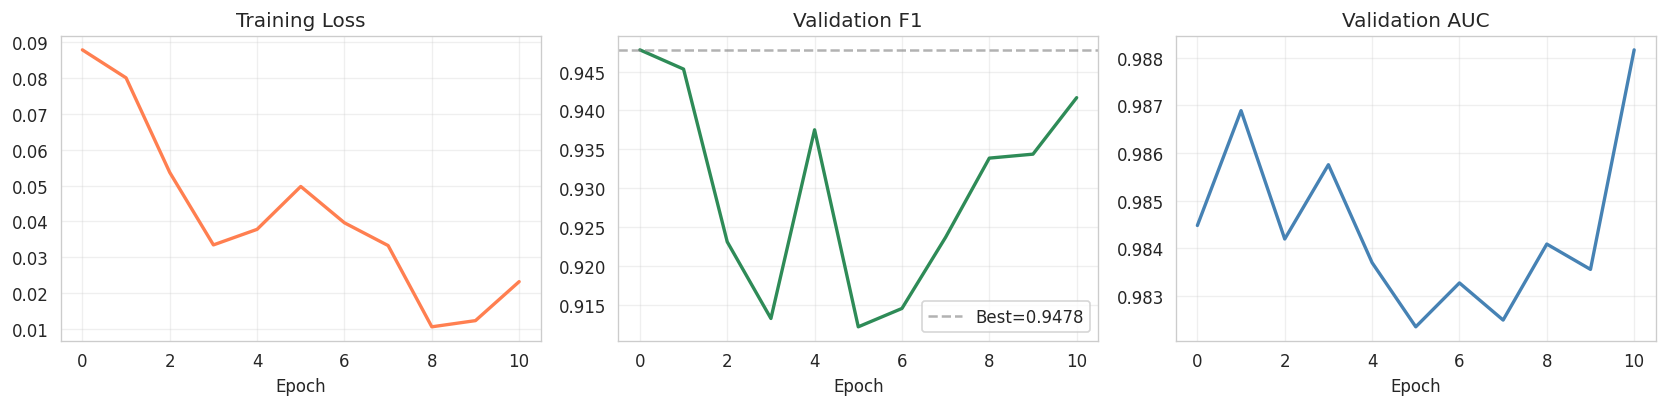

In [32]:
# 训练曲线
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(history['train_loss'], color='coral', lw=2)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(history['val_f1'], color='seagreen', lw=2)
axes[1].axhline(best_f1, color='gray', ls='--', alpha=0.6, label=f'Best={best_f1:.4f}')
axes[1].set_title('Validation F1')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

auc_vals = [v for v in history['val_auc'] if not np.isnan(v)]
if auc_vals:
    axes[2].plot(history['val_auc'], color='steelblue', lw=2)
    axes[2].set_title('Validation AUC')
    axes[2].set_xlabel('Epoch')
    axes[2].grid(alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=20, color='gray')
    axes[2].set_title('Validation AUC')

plt.tight_layout()
plt.show()

---
## 第七步：测试集评估

在未见过的测试集上全面评估模型性能。

In [33]:
test_met = evaluate(model, test_loader, criterion)
print('=' * 50)
print(f'Test set results:')
print(f'  {fmt_metrics(test_met)}')
print('=' * 50)

Test set results:
  Loss:0.1658  Acc:0.9657  Prec:0.9597  Rec:0.9444  F1:0.9520  AUC:0.9875


In [34]:
@torch.no_grad()
def get_all_preds(model, loader):
    model.eval()
    Y, P, Prob = [], [], []
    for X_b, y_b in loader:
        X_b = X_b.to(device)
        logits = model(X_b)
        prob = torch.sigmoid(logits).cpu()
        pred = (prob >= 0.5).float()
        Y.append(y_b)
        P.append(pred)
        Prob.append(prob)
    return torch.cat(Y).numpy().ravel(), torch.cat(P).numpy().ravel(), torch.cat(Prob).numpy().ravel()


y_true, y_pred, y_prob = get_all_preds(model, test_loader)

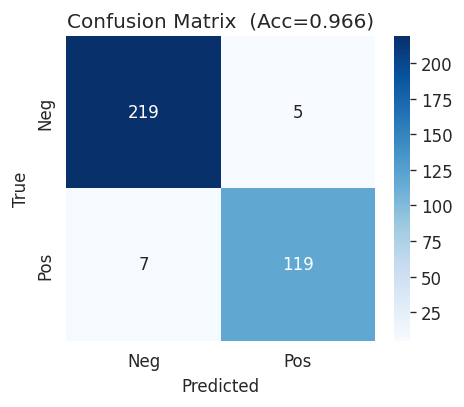

In [35]:
# 混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix  (Acc={test_met["acc"]:.3f})')
plt.tight_layout()
plt.show()

In [36]:
# 分类报告
print('Classification Report')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive'], digits=4))

Classification Report
              precision    recall  f1-score   support

    Negative     0.9690    0.9777    0.9733       224
    Positive     0.9597    0.9444    0.9520       126

    accuracy                         0.9657       350
   macro avg     0.9644    0.9611    0.9627       350
weighted avg     0.9657    0.9657    0.9657       350



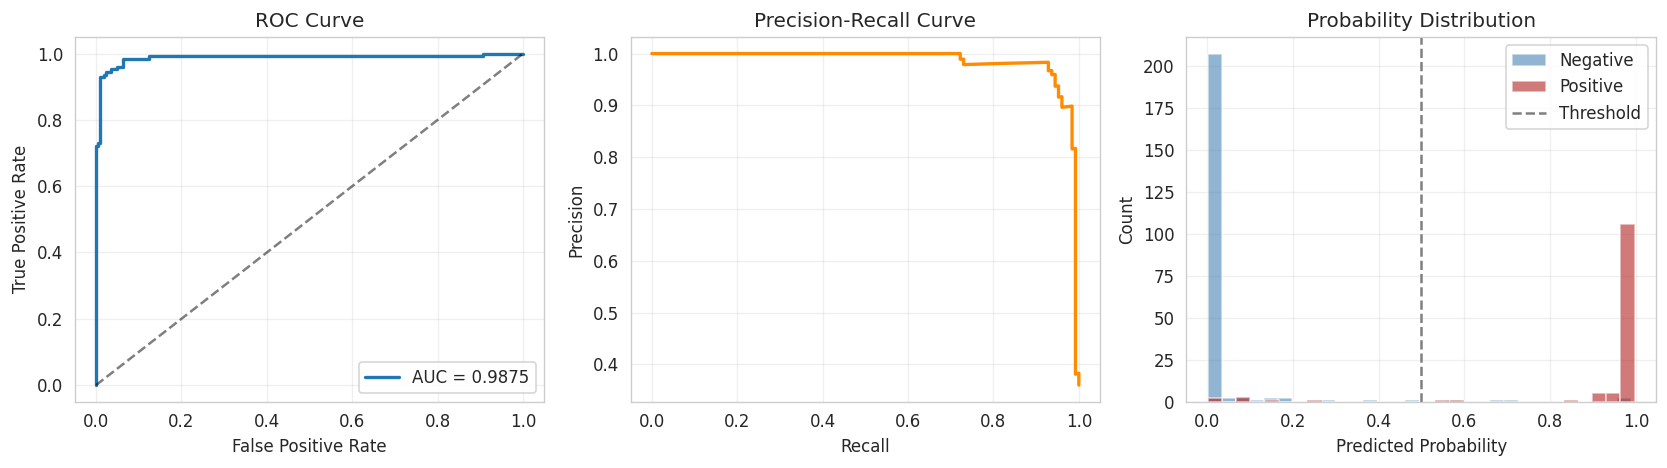

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ROC 曲线
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# PR 曲线
prec, rec, _ = precision_recall_curve(y_true, y_prob)
axes[1].plot(rec, prec, lw=2, color='darkorange')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].grid(alpha=0.3)

# 概率分布
axes[2].hist(y_prob[y_true == 0], bins=30, alpha=0.6, color='steelblue', label='Negative', edgecolor='white')
axes[2].hist(y_prob[y_true == 1], bins=30, alpha=0.6, color='firebrick', label='Positive', edgecolor='white')
axes[2].axvline(0.5, color='gray', ls='--', label='Threshold')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Probability Distribution')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 第八步：预测新序列

输入 FASTA 格式的蛋白质序列，输出每条序列的套索肽概率。

### 示例：手动输入序列测试

In [38]:
# 构建测试用 FASTA 文件
demo_sequences = [
    ('demo_lasso_1', 'MNPKKYSLAQEGVDNVKYLAGSSHGGAVIGTVKHVLEGDKTVTAEVKAKVTIVGNPNSGSSLIGGVTDTLNVGTGKGDVGVDVVK'),
    ('demo_lasso_2', 'MNKEFSLKQPEDAHKTYTQPKPHEWKCDDPKSYCCSWFCCDGYGHYQKICTYPK'),
    ('demo_random_1', 'MKKAVIVENKGLVSDELKANLIDDCRTGDVKVDLLARLDIGKVTKLAKKPGQTSKEFKEAVKAKLDEVKSRL'),
    ('demo_random_2', 'MALRVYADKKSVTIKDGTVTANGKPVKVIEGAKGSVVTGKVEMTLGDDLVIATVKGDKAVVVRGSVGDAVAA'),
    ('insulin', 'MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN')
]

demo_fasta = os.path.join(cfg.DATA_DIR, 'demo_sequences.fasta')
with open(demo_fasta, 'w') as f:
    for sid, seq in demo_sequences:
        f.write(f'>{sid}\n{seq}\n')
print(f'[+] 示例 FASTA 已生成: {demo_fasta}')

[+] 示例 FASTA 已生成: ./lasso_data/demo_sequences.fasta


In [39]:
def predict_fasta(fasta_path, model, tokenizer, esm_model, max_len=100, batch_size=4):
    records = list(SeqIO.parse(fasta_path, 'fasta'))
    seq_ids = [r.id for r in records]
    sequences = [str(r.seq) for r in records]

    # ESM-2 特征提取
    all_embeds = []
    esm_model.eval()
    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch = sequences[i:i + batch_size]
            inputs = tokenizer(batch, return_tensors='pt',
                               padding='max_length', max_length=max_len, truncation=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = esm_model(**inputs)
            hidden = outputs.last_hidden_state
            mask = inputs['attention_mask'].unsqueeze(-1).float()
            all_embeds.append((hidden * mask).cpu())
    embeds = torch.cat(all_embeds, dim=0)

    # 分类器推理
    model.eval()
    with torch.no_grad():
        logits = model(embeds.to(device))
        probs = torch.sigmoid(logits).squeeze(-1).cpu().numpy()

    return pd.DataFrame({
        'sequence_id': seq_ids,
        'probability': probs,
        'prediction': ['positive' if p >= 0.5 else 'negative' for p in probs],
    })

In [41]:
# 加载 ESM-2
tokenizer = EsmTokenizer.from_pretrained(cfg.ESM_MODEL)
esm_model = EsmModel.from_pretrained(cfg.ESM_MODEL).to(device)

df = predict_fasta(demo_fasta, model, tokenizer, esm_model, max_len=cfg.MAX_LEN)
print(df.to_string(index=False))

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  sequence_id  probability prediction
 demo_lasso_1     0.057741   negative
 demo_lasso_2     0.013256   negative
demo_random_1     0.005617   negative
demo_random_2     0.017279   negative
      insulin     0.222719   negative


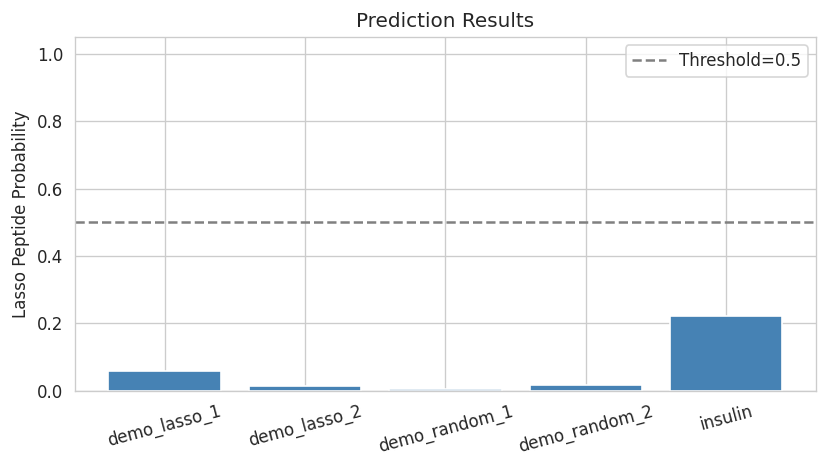

In [42]:
# 概率柱状图
colors = ['firebrick' if p >= 0.5 else 'steelblue' for p in df['probability']]
plt.figure(figsize=(7, 4))
bars = plt.bar(df['sequence_id'], df['probability'], color=colors, edgecolor='white')
plt.axhline(0.5, color='gray', ls='--', label='Threshold=0.5')
plt.ylim(0, 1.05)
plt.ylabel('Lasso Peptide Probability')
plt.title('Prediction Results')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

---
## 第九步：总结与导出

最终产出物：
| 文件 | 说明 |
|------|------|
| `lasso_checkpoints/best_model.pt` | 训练好的模型权重 |
| `lasso_dataset/train.pt` / `val.pt` / `test.pt` | 特征数据集 |
| `lasso_results/` | 评估可视化图表 |
| 本 notebook | 可重复执行的完整流程 |

In [43]:
print('=== 项目摘要 ===')
print(f'模型参数量:     {n_params:,}')
print(f'训练样本:       {len(train_set)}')
print(f'测试 F1:        {test_met["f1"]:.4f}')
print(f'测试 AUC:       {test_met["auc"]:.4f}' if not np.isnan(test_met['auc']) else '测试 AUC: N/A')
print(f'最优 epoch:     {best_epoch}')
print(f'训练耗时:       {time()-t0:.1f}s')
print()
print('运行预测新序列:')
print(f'  python predict.py -i your_sequences.fasta -o results.csv')

=== 项目摘要 ===
模型参数量:     736,385
训练样本:       2797
测试 F1:        0.9520
测试 AUC:       0.9875
最优 epoch:     1
训练耗时:       143.7s

运行预测新序列:
  python predict.py -i your_sequences.fasta -o results.csv
